In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'D:\天池训练赛\训练\tianchi_fresh_comp_train_user.csv')
df.head()

,user_id,item_id,behavior_type,user_geohash,item_category,time
0,10001082,285259775,1,97lk14c,4076,2014-12-08 18
1,10001082,4368907,1,NaN,5503,2014-12-12 12
2,10001082,4368907,1,NaN,5503,2014-12-12 12
3,10001082,53616768,1,NaN,9762,2014-12-02 15
4,10001082,151466952,1,NaN,5232,2014-12-12 11


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23291027 entries, 0 to 23291026
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_id        int64 
 1   item_id        int64 
 2   behavior_type  int64 
 3   user_geohash   object
 4   item_category  int64 
 5   time           object
dtypes: int64(4), object(2)
memory usage: 1.0+ GB


In [4]:
df.value_counts()

user_id    item_id    behavior_type  user_geohash  item_category  time         
24758644   155836094  1              94nutdc       4830           2014-12-11 21    5
103246987  187593746  1              95rwgjo       1797           2014-12-12 20    4
27169453   39512240   1              95qcstc       10392          2014-11-21 16    4
124435826  19308573   1              990cqen       6648           2014-11-29 11    4
27559334   19097257   1              96updik       437            2014-12-02 08    4
                                                                                  ..
39086441   231178644  1              94v0rv9       10894          2014-11-21 13    1
           230078595  1              94vsco5       6936           2014-12-07 22    1
           227993118  1              95lkicr       2953           2014-12-01 12    1
           227790996  1              94vsco6       4370           2014-11-25 21    1
142442955  403495818  1              mtj034e       4370           2014

In [5]:
df.describe()

,user_id,item_id,behavior_type,item_category
count,2.329103e+07,2.329103e+07,2.329103e+07,2.329103e+07
mean,7.006868e+07,2.023214e+08,1.106268e+00,6.835397e+03
std,4.569072e+07,1.167440e+08,4.599087e-01,3.812873e+03
min,4.920000e+02,3.700000e+01,1.000000e+00,2.000000e+00
25%,3.019541e+07,1.014417e+08,1.000000e+00,3.690000e+03
50%,5.626942e+07,2.022430e+08,1.000000e+00,6.054000e+03
75%,1.166482e+08,3.035325e+08,1.000000e+00,1.027100e+04
max,1.424430e+08,4.045625e+08,4.000000e+00,1.408000e+04


In [6]:
import seaborn as sns
import matplotlib.pyplot as plot

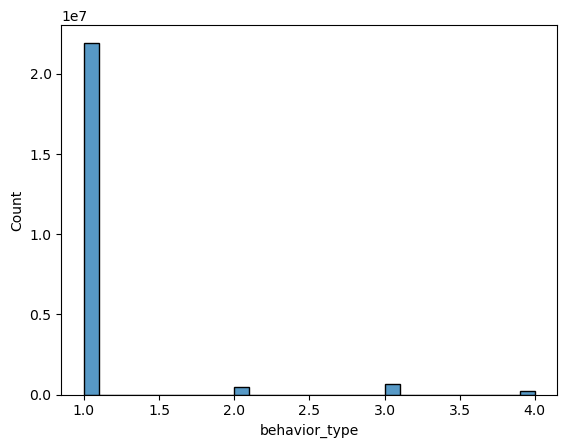

In [7]:
sns.histplot(data = df,x="behavior_type",binwidth=.1)
plot.show()

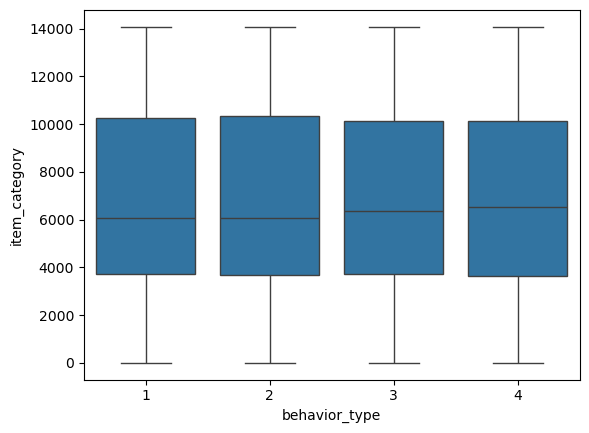

In [8]:
sns.boxplot(data = df ,x="behavior_type",y ="item_category")
plot.show()

In [9]:
#2
df[df["item_category"].isin(["4076","5503"])].head()

,user_id,item_id,behavior_type,user_geohash,item_category,time


In [10]:
df.select_dtypes("int64").head()

,user_id,item_id,behavior_type,item_category
0,10001082,285259775,1,4076
1,10001082,4368907,1,5503
2,10001082,4368907,1,5503
3,10001082,53616768,1,9762
4,10001082,151466952,1,5232


In [11]:
df["item_category"].min()

2

In [12]:
df["item_category"].max()

14080

In [13]:
#data summarization
df[["behavior_type","user_id","item_id"]].groupby("user_id").mean()

,behavior_type,item_id
user_id,,
492,1.108614,2.151023e+08
3726,1.043038,2.121933e+08
19137,1.035714,2.345674e+08
36465,1.074627,2.027029e+08
37101,1.080754,2.152928e+08
...,...,...
142427508,1.180233,2.187522e+08
142432272,1.029925,2.073432e+08
142439559,1.000000,1.860095e+08


In [14]:
df[["user_id","item_id"]].agg(["mean","std"])

,user_id,item_id
mean,7.006868e+07,2.023214e+08
std,4.569072e+07,1.167440e+08


In [15]:
df.agg({"user_id":["mean","std"],"item_id":["median"]})

,user_id,item_id
mean,7.006868e+07,NaN
std,4.569072e+07,NaN
median,NaN,202242969.0


In [17]:
df.groupby("behavior_type").agg(mean_user_id=("user_id","mean"),std_user_id=("user_id","std"),
median_item_id=("item_id","median"))

,mean_user_id,std_user_id,median_item_id
behavior_type,,,
1,7.008786e+07,4.568673e+07,202246709.0
2,7.015487e+07,4.541822e+07,202342745.0
3,6.938801e+07,4.598208e+07,201831524.0
4,7.001919e+07,4.575922e+07,202833694.0


In [ ]:
#sns.barplot(data = df ,x = "behavior_type",y = "user_id")
#plot.show()